In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from tensorflow import keras


dataset_path = "/content/drive/MyDrive/PlantDesease/PlantLeafDataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
model_path = "/content/drive/MyDrive/PlantDesease/TrainedModel/best_model.keras"


image_size = (224, 224)
batch_size = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='categorical',
    image_size=image_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)


model = tf.keras.models.load_model(model_path)

print("Dataset and model loaded successfully.")

Found 70295 files belonging to 38 classes.
Dataset and model loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
for images, labels in train_ds.take(1):
    images = tf.cast(images, tf.float32) / 255.0
    num_images_to_display = 30
    sample_images = images[:num_images_to_display]
    sample_labels = labels[:num_images_to_display]

print(f"Selected {sample_images.shape[0]} images and labels for visualization.")

Selected 30 images and labels for visualization.


In [5]:
import numpy as np
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )


    with tf.GradientTape() as tape:
        last_conv_layer_output, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    raise ValueError("Could not find a convolutional layer in the model.")

expected_input_shape = tuple(model.input_shape[1:4]) # Exclude batch size

heatmaps = []
for img in sample_images:
    img_resized = tf.image.resize(img, expected_input_shape[:2])
    img_array = tf.expand_dims(img_resized, axis=0)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmaps.append(heatmap)

print(f"Generated {len(heatmaps)} heatmaps.")

Generated 30 heatmaps.


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib.cm as cm

def save_and_display_gradcam(original_image, heatmap, alpha=0.5, heatmap_size=(128, 128)):
    heatmap = heatmap.astype(np.float32)

    target_size = (int(heatmap_size[0]), int(heatmap_size[1]))
    if target_size[0] <= 0 or target_size[1] <= 0:
        print("Error: Target heatmap size is invalid.")
        return

    try:
        heatmap_resized_for_overlay = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    except cv2.error as e:
        print(f"Error during resize: {e}")
        print(f"Heatmap shape before resize: {heatmap.shape}")
        print(f"Target size: {(original_image.shape[1], original_image.shape[0])}")
        return

    heatmap_colored = np.uint8(255 * heatmap_resized_for_overlay)
    colormap = cm.get_cmap("jet")
    heatmap_colored = (colormap(heatmap_colored)[..., :3] * 255).astype(np.uint8) # Apply colormap and get RGB, ensure uint8

    if len(heatmap_colored.shape) == 2: # If grayscale, convert to BGR
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_GRAY2BGR)
    elif len(heatmap_colored.shape) == 3 and heatmap_colored.shape[2] == 4: # If RGBA, convert to BGR
         heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_RGBA2BGR)
    elif len(heatmap_colored.shape) == 3 and heatmap_colored.shape[2] == 3: # If RGB, convert to BGR
         heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_RGB2BGR)


    if len(original_image.shape) == 3 and original_image.shape[2] == 3: # If RGB, convert to BGR
         original_image_bgr = cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR)
    else:
         original_image_bgr = original_image


    if original_image_bgr.shape[:2] != heatmap_colored.shape[:2]:
        print("Error: Image dimensions mismatch before overlay.")
        print(f"Original image (BGR) shape: {original_image_bgr.shape}")
        print(f"Heatmap colored shape: {heatmap_colored.shape}")
        return



    original_image_float = original_image_bgr.astype(np.float32)
    heatmap_colored_float = heatmap_colored.astype(np.float32)


    superimposed_img = heatmap_colored_float * alpha + original_image_float * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)


    superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)



    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image.astype(np.uint8))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img_rgb)
    plt.title("Grad-CAM Visualization")
    plt.axis("off")
    plt.show()


for i in range(len(sample_images)):
    original_img_display = (sample_images[i].numpy() * 255).astype(np.uint8)
    save_and_display_gradcam(original_img_display, heatmaps[i], alpha=0.5, heatmap_size=original_img_display.shape[:2])

Output hidden; open in https://colab.research.google.com to view.

#Grad-CAM++

In [7]:
import numpy as np
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras

def make_gradcam_heatmap_plus(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape(persistent=True) as tape:
        last_conv_layer_output, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, last_conv_layer_output)

        second_grads = tape.gradient(grads, last_conv_layer_output)

    grads_squared = tf.square(grads)
    grads_cubed = tf.pow(grads, 3)



    epsilon = 1e-7
    denominator = 2 * grads_squared + last_conv_layer_output * grads_cubed + epsilon
    alpha_num = grads_squared
    alpha = alpha_num / denominator

    alpha_pooled = tf.reduce_sum(alpha, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output * alpha_pooled

    heatmap = tf.reduce_sum(heatmap, axis=-1)


    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    raise ValueError("Could not find a convolutional layer in the model.")

expected_input_shape = tuple(model.input_shape[1:4]) # Exclude batch size

heatmaps = []
for img in sample_images:
    img_resized = tf.image.resize(img, expected_input_shape[:2])
    img_array = tf.expand_dims(img_resized, axis=0)
    heatmap = make_gradcam_heatmap_plus(img_array, model, last_conv_layer_name)
    heatmaps.append(heatmap)

print(f"Generated {len(heatmaps)} heatmaps.")

Generated 30 heatmaps.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib.cm as cm
import matplotlib

def save_and_display_gradcam_plus(original_image, heatmap, alpha=0.5, heatmap_size=(128, 128)):
    heatmap = heatmap.astype(np.float32)

    target_size = (int(heatmap_size[0]), int(heatmap_size[1]))
    if target_size[0] <= 0 or target_size[1] <= 0:
        print("Error: Target heatmap size is invalid.")
        return

    try:
        heatmap_resized_for_overlay = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    except cv2.error as e:
        print(f"Error during resize: {e}")
        print(f"Heatmap shape before resize: {heatmap.shape}")
        print(f"Target size: {(original_image.shape[1], original_image.shape[0])}")
        return

    heatmap_colored = np.uint8(255 * heatmap_resized_for_overlay)
    colormap = matplotlib.colormaps.get_cmap("jet")
    heatmap_colored = (colormap(heatmap_colored)[..., :3] * 255).astype(np.uint8)

    if len(heatmap_colored.shape) == 2:
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_GRAY2BGR)
    elif len(heatmap_colored.shape) == 3 and heatmap_colored.shape[2] == 4:
         heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_RGBA2BGR)
    elif len(heatmap_colored.shape) == 3 and heatmap_colored.shape[2] == 3:
         heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_RGB2BGR)


    if len(original_image.shape) == 3 and original_image.shape[2] == 3:
         original_image_bgr = cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR)
    else:
         original_image_bgr = original_image


    if original_image_bgr.shape[:2] != heatmap_colored.shape[:2]:
        print("Error: Image dimensions mismatch before overlay.")
        print(f"Original image (BGR) shape: {original_image_bgr.shape}")
        print(f"Heatmap colored shape: {heatmap_colored.shape}")
        return


    original_image_float = original_image_bgr.astype(np.float32)
    heatmap_colored_float = heatmap_colored.astype(np.float32)


    superimposed_img = heatmap_colored_float * alpha + original_image_float * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)

    superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)


    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image.astype(np.uint8))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img_rgb)
    plt.title("Grad-CAM++ Visualization")
    plt.axis("off")
    plt.show()


for i in range(len(sample_images)):
    original_img_display = (sample_images[i].numpy() * 255).astype(np.uint8)
    save_and_display_gradcam_plus(original_img_display, heatmaps[i], alpha=0.5, heatmap_size=original_img_display.shape[:2]) # Pass original image shape and adjusted alpha

Output hidden; open in https://colab.research.google.com to view.

In [9]:
from google.colab import files
from PIL import Image
import numpy as np
import tensorflow as tf

uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename).convert('RGB')
    img_array = np.array(img)


img_resized = tf.image.resize(img_array, expected_input_shape[:2])

img_array_processed = tf.expand_dims(img_resized, axis=0)

print(f"Uploaded and processed image: {filename}")

Saving RS_Rust 1563_flipLR.JPG to RS_Rust 1563_flipLR.JPG
Uploaded and processed image: RS_Rust 1563_flipLR.JPG


In [10]:

grad_cam_heatmap = make_gradcam_heatmap(img_array_processed, model, last_conv_layer_name)

grad_cam_plus_plus_heatmap = make_gradcam_heatmap_plus(img_array_processed, model, last_conv_layer_name)

print("Generated Grad-CAM and Grad-CAM++ heatmaps.")

Generated Grad-CAM and Grad-CAM++ heatmaps.


Visualizing Grad-CAM:


/tmp/ipython-input-4121051907.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


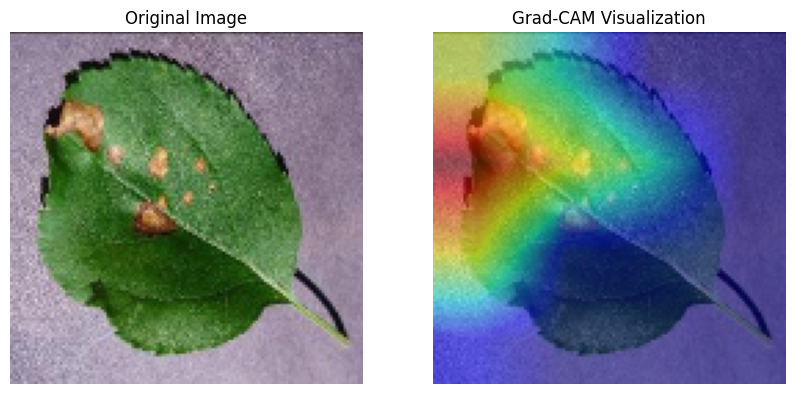

Visualizing Grad-CAM++:


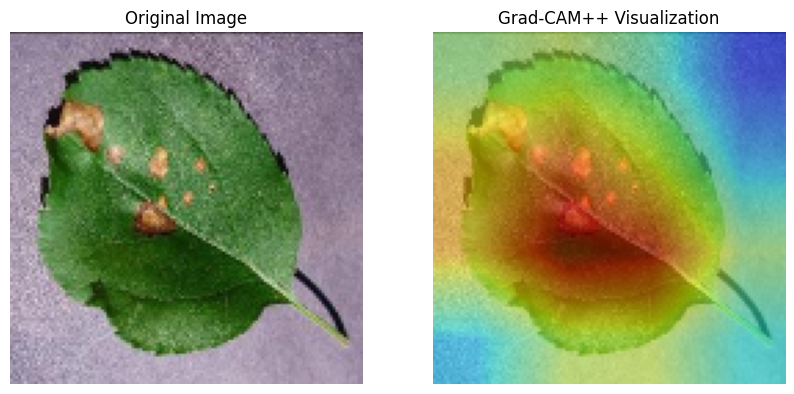

In [ ]:

original_img_display = (img_resized.numpy()).astype(np.uint8)

print("Visualizing Grad-CAM:")
save_and_display_gradcam(original_img_display, grad_cam_heatmap, alpha=0.5, heatmap_size=original_img_display.shape[:2])

print("Visualizing Grad-CAM++:")
save_and_display_gradcam_plus(original_img_display, grad_cam_plus_plus_heatmap, alpha=0.5, heatmap_size=original_img_display.shape[:2])

/tmp/ipython-input-95225337.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


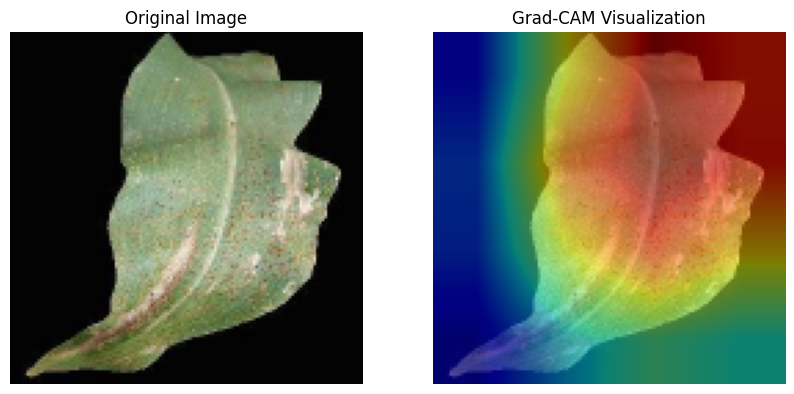

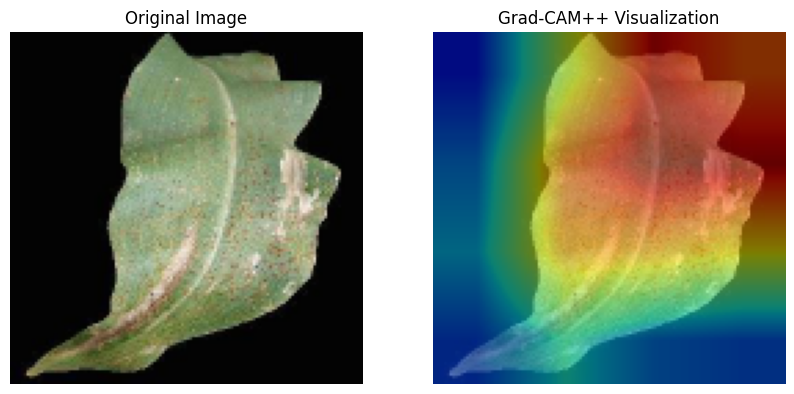

In [11]:

original_img_display = (img_resized.numpy()).astype(np.uint8)

save_and_display_gradcam(original_img_display, grad_cam_heatmap, alpha=0.5, heatmap_size=original_img_display.shape[:2])

save_and_display_gradcam_plus(original_img_display, grad_cam_plus_plus_heatmap, alpha=0.5, heatmap_size=original_img_display.shape[:2])